# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

[Dataset Source on Kaggle](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/data)
  </p>
</details>

## To Do List

- [ ] Try to change a bit in the neural network, to see if we can get better accuracies.
- [ ] Do a better evaluation, some confusion matrix and balanced accuracy.
- [ ] change validation to test ka name
- [ ] ballesh tobyid ... the text and explanation... COPILOTEH.
- [ ] Plot the most frequent per n-gram.
- [ ] remove @ in the cleaning

## Imports

In [15]:
# import kagglehub
import pandas as pd
import html
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import seaborn as sns
import matplotlib.pyplot as plt

import emoji
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Download NLTK resources if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\raad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 📊 EDA

In this study, we focus exclusively on the `training.1600000.processed.noemoticon.csv` dataset, deliberately excluding the `train.csv` and `test.csv` files from our analysis. This choice is motivated by the richness and scale of the selected dataset, which contains ~1 million tweets and offers a more comprehensive foundation for sentiment analysis.

To begin, we load the dataset and perform initial preprocessing steps. Specifically, we rename the columns `polarity of tweet\xa0` and `text of the tweet\xa0` to `polarity` and `text`, respectively, to simplify references and improve code readability throughout the notebook.

In [3]:
train_df = pd.read_csv("../Data/train_data.csv", encoding="Windows-1252")
train_df.rename(
    columns={
        'polarity of tweet\xa0' : 'polarity',
        'text of the tweet\xa0' : 'text'
    },
    inplace = True
)

train_df.head()

,polarity,id of the tweet,date of the tweet,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


The dataset also includes additional fields such as `id of the tweet`, `date of the tweet`, `query`, and `user`. However, these fields are not relevant for our sentiment analysis task and will be discarded. We retain only the `polarity` and `text` columns, which contain the sentiment label and the tweet content—our primary variables of interest.

In [4]:
train_df = train_df[["text", "polarity"]]

print(f"train has {len(train_df)} rows")

train has 1048572 rows


Before proceeding with further analysis, we perform a preliminary check for missing values in the dataset. This step ensures data integrity and helps avoid unexpected issues during preprocessing or modeling.

In [5]:
print("train Nans")
print(train_df.isnull().sum())

train Nans
text        0
polarity    0
dtype: int64


Upon inspection, we confirm that there are no missing values in the dataset. This allows us to move forward confidently with the sentiment analysis pipeline without the need for imputation or data cleaning related to null entries.

To prepare the tweet content for analysis, we apply a basic text cleaning function. This step helps standardize the input and remove superficial variations that do not affect sentiment.
Specifically, we:

- Decode any HTML entities,
- Normalize whitespace,
- Convert all text to lowercase,
- Strip leading and trailing spaces.

These transformations ensure consistency across the dataset, as variations in capitalization or spacing do not carry meaningful sentiment information. The cleaning function used is as follows:

In [6]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [7]:
train_df["text"] = train_df["text"].apply(basic_text_clean)

With the text now standardized, we proceed to check for duplicate entries in the dataset. Duplicate tweets can introduce bias and inflate the influence of repeated content, which may distort the sentiment distribution and model performance.

In [8]:
has_duplicates = train_df.duplicated().any()

print("train_df has duplicates:", has_duplicates)

train_df has duplicates: True


Upon inspection, we find that the dataset does contain duplicate entries. To ensure the integrity and diversity of the data, we remove all duplicates based on the text column. This step helps reduce redundancy and ensures that each tweet contributes uniquely to the sentiment analysis process.

In [9]:
before = len(train_df)

train_df.drop_duplicates(inplace=True)

print(f"{before - len(train_df)} rows are dropped")

print(f"dataset has {len(train_df)} rows")

15020 rows are dropped
dataset has 1033552 rows


Next, we examine the distribution of the target variable, `polarity`, which indicates the sentiment of each tweet. The dataset uses two labels:  
- `0` for **negative** sentiment  
- `4` for **positive** sentiment

A quick visualization reveals a **highly imbalanced** distribution. The number of negative tweets (polarity `0`) is significantly greater than the number of positive tweets (polarity `4`). Specifically, there are close to **800,000 negative samples** compared to just under **300,000 positive samples**.

This imbalance is an important consideration for model training, as it may lead to biased predictions favoring the majority class. We will address this issue in later stages of the pipeline.

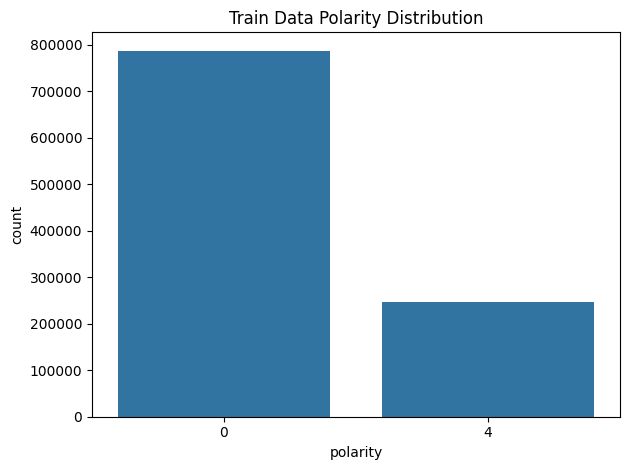

In [10]:
# Train data polarity distribution
sns.countplot(data=train_df, x="polarity")
plt.title("Train Data Polarity Distribution")

plt.tight_layout()

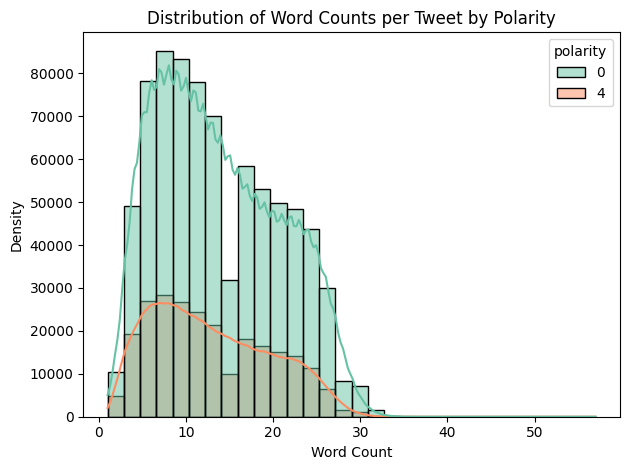

In [11]:
# Calculate word counts
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

# Plot KDE with hue based on polarity

sns.histplot(data=train_df, x='word_count', hue='polarity', kde=True, common_norm=False, palette='Set2', bins=30)
plt.title('Distribution of Word Counts per Tweet by Polarity')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.tight_layout()

The plot above illustrates the distribution of word counts per tweet, differentiated by sentiment polarity. It combines a histogram with KDE (Kernel Density Estimation) overlays to provide both frequency and smooth density estimates.

- **Polarity 0 (Negative)** tweets are shown in green.
- **Polarity 4 (Positive)** tweets are shown in orange.

Both distributions peak around **10 words**, indicating that most tweets—regardless of sentiment—are relatively short. However, tweets with negative sentiment (polarity 0) are more frequent across all word count ranges, reflecting the earlier observation of class imbalance.

This visualization helps us understand the typical length of tweets and confirms that tweet length does not vary significantly between sentiment classes, though the volume of negative tweets is consistently higher.

## 📝 Text Preprocessing

To enhance the quality of the textual data for sentiment analysis, we apply a more comprehensive preprocessing pipeline. This includes removing URLs, HTML tags, and hashtags (while retaining the associated text), followed by tokenization. We then eliminate stopwords to reduce noise and apply lemmatization to normalize word forms. Additional cleaning steps include removing numerical characters and punctuation. These transformations help reduce variability in the data and ensure that the model focuses on semantically meaningful content, ultimately improving the robustness of downstream analysis and classification.

During preprocessing, we observed that many tweets contain informal contractions such as *"gonna"*, *"I'm"*, or *"don't"*, which can negatively affect tokenization and downstream analysis. To address this, we use `contractions.fix()` to expand these expressions into their full forms (e.g., `"I'm gonna do it 😁"` becomes `"I am going to do it 😁"`), improving clarity and consistency.

Additionally, tweets often include emojis, which can carry strong sentiment signals. Instead of removing them, we apply `emoji.demojize()` to convert emojis into descriptive text (e.g., `😁` becomes `:beaming_face_with_smiling_eyes:`), allowing us to retain their emotional context for sentiment classification.

In [17]:
emoji.demojize("😁")

':beaming_face_with_smiling_eyes:'

In [71]:
contractions.fix("I'm gonna do it 😁")

'I am going to do it 😁'

In [68]:
contractions.fix("I dunno")

'I do not know'

In [72]:
contractions.fix("I dunno")
contractions.fix("I don't know")

'I do not know'

In [74]:
import string 

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {"no", "nor", "not"} # We keep negations

def text_preprocess(text):
    # Remove urls
    text = re.sub(r'(https?://\S+|www\.\S+|\b\w+\.(com|org|net|edu|gov|info|io|co|me|ai)\b\S*)', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove contractions
    text = contractions.fix(text)
    if not isinstance(text, str):
        raise ValueError("text should be a string")
    # Make emojis to tags
    text = emoji.demojize(text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[{}]'.format(re.escape(string.punctuation)), ' ', text).strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Join tokens back into text
    text = ' '.join(tokens)
    return text

In [76]:
"the" in stop_words

True

In [62]:
text_preprocess("http://www.google.com is not #awesome! 😔")

'not awesome pensive face'

The advanced preprocessing function is computationally intensive and takes approximately 5 to 6 minutes to process the entire dataset. 

In [63]:
train_df["preprocessed_text"] = train_df["text"].apply(text_preprocess)

Checking the top 20 texts

In [64]:
train_df[["text", "preprocessed_text"]].head(10)

,text,preprocessed_text
0,is upset that he can't update his facebook by ...,upset not update facebook texting might cry re...
1,@kenichan i dived many times for the ball. man...,kenichan dived many time ball managed save res...
2,my whole body feels itchy and like its on fire,whole body feel itchy like fire
3,"@nationwideclass no, it's not behaving at all....",nationwideclass no not behaving mad not see
4,@kwesidei not the whole crew,kwesidei not whole crew
5,need a hug,need hug
6,@loltrish hey long time no see! yes.. rains a ...,loltrish hey long time no see yes rain bit bit...
7,i just re-pierced my ears,pierced ear
8,@caregiving i couldn't bear to watch it. and i...,caregiving could not bear watch thought ua los...
9,"@octolinz16 it it counts, idk why i did either...",octolinz count not know either never talk anymore


### Train - Test Split

In [77]:
from sklearn.model_selection import train_test_split

X = train_df[["preprocessed_text"]]
y = train_df[["polarity"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=True, stratify=train_df["polarity"])

In [92]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 4), max_features=2048)
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(X_train["preprocessed_text"])
tfidf_ngram_vectorizer_test = tfidf_ngram_vectorizer.transform(X_test["preprocessed_text"])
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]

array(['chicken', 'child', 'chocolate', 'chris', 'church', 'city',
       'class', 'clean', 'cleaning', 'close'], dtype=object)

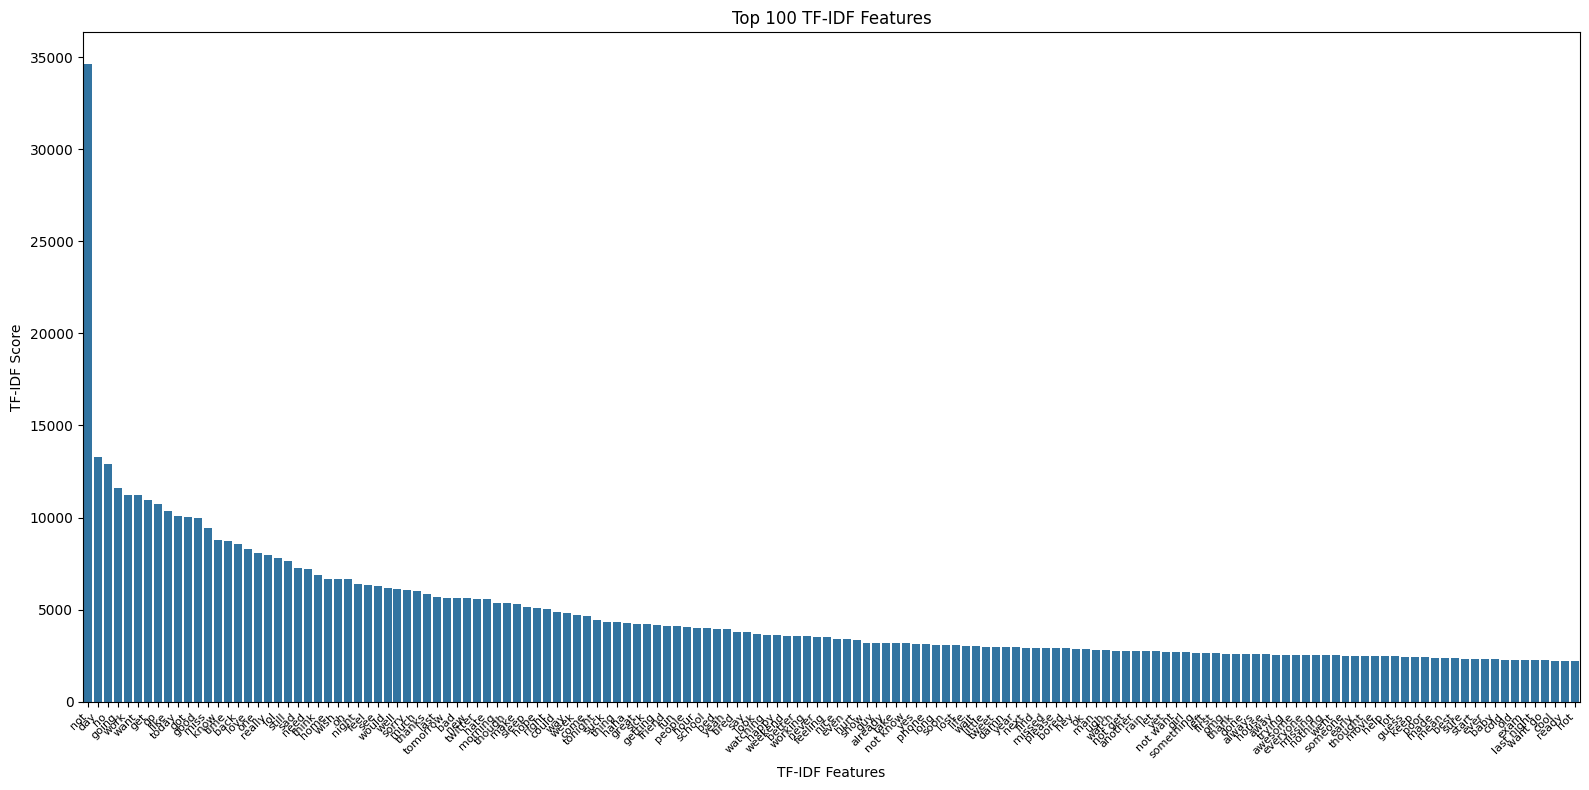

In [93]:
# Get feature names and summed TF-IDF values
feature_array = tfidf_ngram_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_ngram_vectorizer_train.sum(axis=0).A1
tfidf_freq_df = pd.DataFrame({'feature': feature_array, 'tfidf_sum': tfidf_scores})


feature_scores = pd.DataFrame({'feature': feature_array, 'score': tfidf_scores})

# Get top 100 features by score
top_features = feature_scores.nlargest(150, 'score')

# Plot using seaborn with flipped axes and rotated x-axis labels
plt.figure(figsize=(16, 8))
sns.barplot(data=top_features, x='feature', y='score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.xlabel("TF-IDF Features")
plt.ylabel("TF-IDF Score")
plt.title("Top 100 TF-IDF Features")
plt.tight_layout()
plt.show()

In [94]:
train_vectors = tfidf_ngram_vectorizer_train.toarray()
print(train_vectors.shape)
test_vectors = tfidf_ngram_vectorizer_test.toarray()
print(test_vectors.shape)

(723486, 1137)
(310066, 1137)


In [95]:
# converting the features_train and features_validation 
train_vectors = torch.tensor(train_vectors, dtype=torch.float32)
test_vectors = torch.tensor(test_vectors, dtype=torch.float32)

## Model + Training + Eval

In [98]:
train_vectors.shape

torch.Size([723486, 1137])

In [99]:
# convert target variables into pytorch tensors
label_map = {0: 0, 4: 1}

y_train = torch.tensor(y_train["polarity"].map(label_map).to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test["polarity"].map(label_map).to_numpy(), dtype=torch.long)

C:\Users\raad\AppData\Local\Temp\ipykernel_25240\878041792.py:4: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  y_train = torch.tensor(y_train["polarity"].map(label_map).to_numpy(), dtype=torch.long)


IndexError: too many indices for tensor of dimension 1

In [100]:
y_train.shape
y_test.shape

torch.Size([310066])

In [101]:
# initialise TensorDataset  object
train_dataset = TensorDataset(train_vectors, y_train)
val_dataset = TensorDataset(test_vectors, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [102]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size=16, output_size=2, dropout_rate=0.43):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # No activation here; use CrossEntropyLoss during training

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits

In [103]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [104]:
num_epochs = 10  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/10, Loss: 0.4188, Val Loss: 0.4003
Epoch 2/10, Loss: 0.3988, Val Loss: 0.3993
Epoch 3/10, Loss: 0.3974, Val Loss: 0.3987
Epoch 4/10, Loss: 0.3971, Val Loss: 0.3987
Epoch 5/10, Loss: 0.3967, Val Loss: 0.3983
Epoch 6/10, Loss: 0.3963, Val Loss: 0.3983
Epoch 7/10, Loss: 0.3957, Val Loss: 0.3983
Epoch 8/10, Loss: 0.3952, Val Loss: 0.3982
Epoch 9/10, Loss: 0.3952, Val Loss: 0.3981
Epoch 10/10, Loss: 0.3952, Val Loss: 0.3984


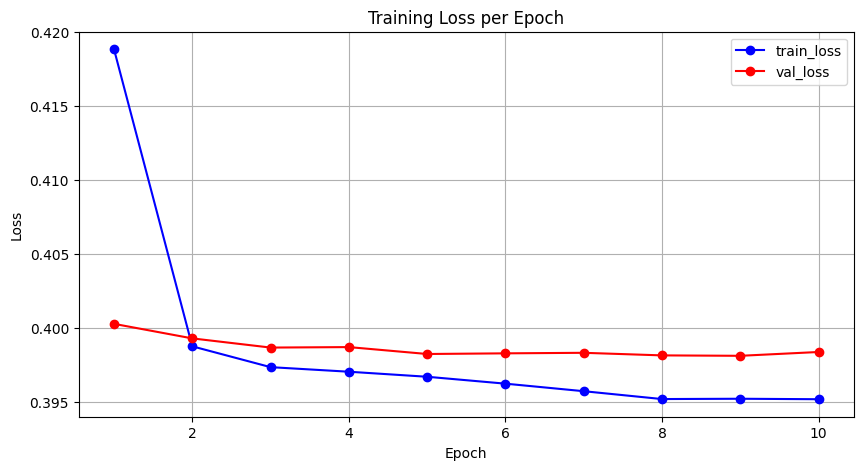

In [105]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [106]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 83.10%
Validation Accuracy: 82.85%


In [ ]:
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # First hidden layer with 4 neurons
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.61)

        self.fc2 = nn.Linear(128, 16)  # Second hidden layer with 3 neurons
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(16, 3)  # Output layer with 3 neurons (for 3 sentiment classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)  # raw logits for CrossEntropyLoss
        return x


In [ ]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
num_epochs = 10  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/10, Loss: 0.4306, Val Loss: 0.4097
Epoch 2/10, Loss: 0.4062, Val Loss: 0.4070
Epoch 3/10, Loss: 0.4028, Val Loss: 0.4041
Epoch 4/10, Loss: 0.4001, Val Loss: 0.4036
Epoch 5/10, Loss: 0.3977, Val Loss: 0.4037
Epoch 6/10, Loss: 0.3958, Val Loss: 0.4032
Epoch 7/10, Loss: 0.3943, Val Loss: 0.4030
Epoch 8/10, Loss: 0.3924, Val Loss: 0.4033
Epoch 9/10, Loss: 0.3910, Val Loss: 0.4039
Epoch 10/10, Loss: 0.3895, Val Loss: 0.4035


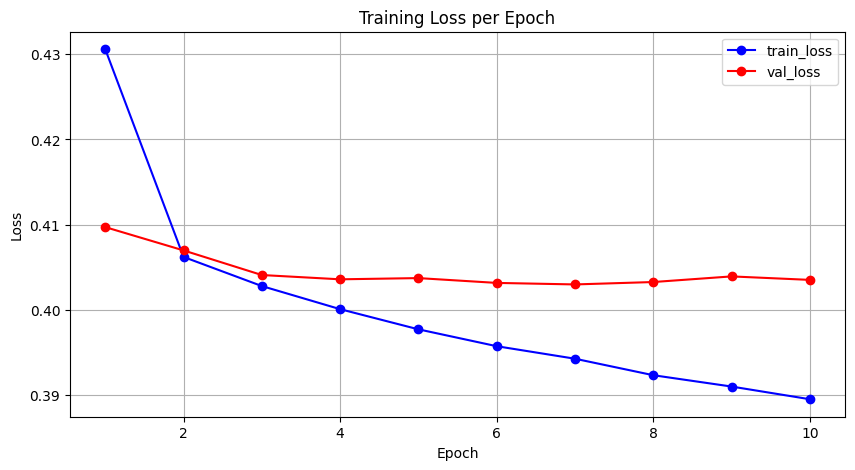

In [ ]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 83.41%
Validation Accuracy: 82.24%
